<a href="https://colab.research.google.com/github/miyu-cell/satdat2024-tweet-classification/blob/main/Satdat2024_Tweet_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Train Pre-processing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as ply
import tensorflow as tf
import re
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/bdc/dataset_penyisihan_bdc_2024(in).csv', sep=';')

In [ ]:
df


,text,label
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,Demografi
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,Politik
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik
...,...,...
4995,RT @l1DsGGe2xObT3t72dHwqlT58X7jvEYtEnauZIZSYwS...,Politik
4996,Masyarakat yakin bahwa Prabowo-Gibran memiliki...,Politik
4997,imo both are irrational but yg satu jauh lebih...,Ekonomi
4998,@cIIGSdjaPrmAQY1E4gWnLpIZSdyQn8ZMhjJzgOsxfRM= ...,Pertahanan dan Keamanan


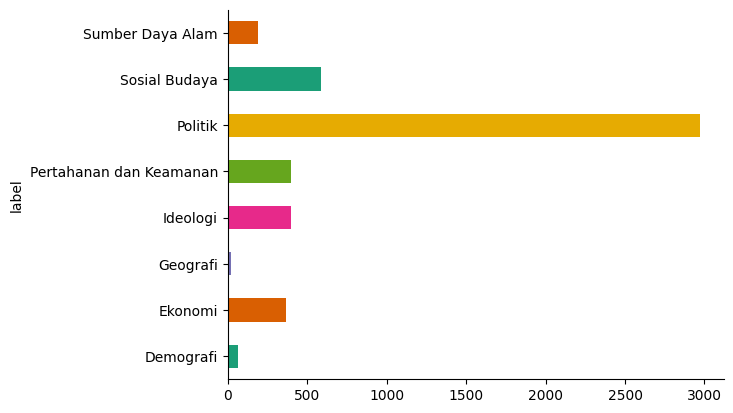

In [ ]:
# @title label

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df=df.drop_duplicates(subset=['text'])

In [ ]:
df.shape

(4583, 2)

In [ ]:
def clean_text_simple(text):
    #Removing URLs and user mentions
    text = re.sub(r'http\S+|www\S+|@\S+', '', text)
    #Removing numbers
    text = re.sub(r'\d+', '', text)
    #Removing extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].apply(clean_text_simple)
df[['text', 'label']].head()

,text,label
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik
2,"emng bener sih, pendukung ada yg goblok, begit...",Demografi
3,RT Sewaktu anies bersikap kritis ke kinerja pa...,Politik
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik


In [ ]:
def clean_text(res):
        res = re.sub(r'[^\x00-\x7F]+',' ', res)
        res = re.sub(r'http[s]?\:\/\/.[a-zA-Z0-9\.\/\_?=%&#\-\+!]+',' ', res)
        res = re.sub(r'pic.twitter.com?.[a-zA-Z0-9\.\/\_?=%&#\-\+!]+',' ', res)
        res = re.sub(r'\@([\w]+)',' ', res)
        res=re.sub(r'RT[\s]+', ' ',res)
        res = re.sub(r'\#([\w]+)',' ', res)
        res = re.sub(r'[!$%^&*@#()_+|~=`{}\[\]%\-:";\'<>?,.\/]', ' ', res)
        res = re.sub(r'[0-9]+','', res)
        res = re.sub(r'([a-zA-Z])\1\1','\\1', res)
        res = re.sub(' +', ' ', res)
        res = re.sub(r'^[ ]|[ ]$','', res)
        res = res.lower()
        return res

df['text']=df['text'].apply(clean_text)

In [ ]:
df = df[df['text'].str.strip() != ""]

In [ ]:
df

,text,label
0,kunjungan prabowo ini untuk meresmikan dan men...,Sumber Daya Alam
1,anies dapat tepuk tangan meriah saat jadi rekt...,Politik
2,emng bener sih pendukung ada yg goblok begitu ...,Demografi
3,sewaktu anies bersikap kritis ke kinerja pak p...,Politik
4,anies baswedan harap asn termasuk tni dan polr...,Politik
...,...,...
4995,ngeliat debat kemaren pas prabowo kicep kekira...,Politik
4996,masyarakat yakin bahwa prabowo gibran memiliki...,Politik
4997,imo both are irrational but yg satu jauh lebih...,Ekonomi
4998,look at that pak ganjar anda sdh berkecimpung ...,Pertahanan dan Keamanan


In [ ]:
df.to_csv('/content/drive/My Drive/bdc/dataset/5000.csv', index=False)

In [ ]:
grouped_df = df.groupby('label')

#Mengambil data masing-masing kategori
ideologi_df = grouped_df.get_group('Ideologi')
politik_df = grouped_df.get_group('Politik')
ekonomi_df = grouped_df.get_group('Ekonomi')
sosbud_df = grouped_df.get_group('Sosial Budaya')
hankam_df = grouped_df.get_group('Pertahanan dan Keamanan')
sda_df = grouped_df.get_group('Sumber Daya Alam')
geografi_df = grouped_df.get_group('Geografi')
demografi_df = grouped_df.get_group('Demografi')

In [ ]:
geografi_df

,text,label
238,malam tahun baru ganjar salawatan amp istighos...,Geografi
304,jangan golput pilih capres no ganjar pranowo m...,Geografi
529,di tiktok ada yg bilang anies kepengen bangun ...,Geografi
832,kuliah gratis dampaknya bisa utk semua anak ba...,Geografi
920,owi dan org nya ngerti pasti bkl panen cuan ba...,Geografi
1180,lu paling gblok lu liat tuh pulau reklamasi be...,Geografi
1607,kata siapa nih sumbernya food estate gunung ma...,Geografi
2046,dulu marah ke pak anies waktu pulau reklamasi ...,Geografi
2142,setiap temen w komentar anies mah janji doang ...,Geografi
2582,ditakedown di jakarta amp bekasi videotron pak...,Geografi


In [ ]:
print(ideologi_df[['text']].head(), "\n")
print(politik_df[['text']].head(), "\n")
print(ekonomi_df[['text']].head(), "\n")
print(sosbud_df[['text']].head(), "\n")
print(hankam_df[['text']].head(), "\n")
print(sda_df[['text']].head(), "\n")
print(geografi_df[['text']].head(), "\n")
print(demografi_df[['text']].head(), "\n")

label_counts = df['label'].value_counts()

#Menampilkan jumlah tweet dalam setiap kategori
print("Jumlah Tweet Berdasarkan Kategori:")
print(label_counts)

                                                 text
10  beberapa isu basi terkait dan fakta sebenarnya...
32  capres cawapres ganjar pranowo dan mahfud md m...
38  anak muda indonesia the future of this nation ...
78  calon presiden ri no urut ganjar pranowo gak m...
81  capres ganjar pranowo yakin konstitusi atau at... 

                                                text
1  anies dapat tepuk tangan meriah saat jadi rekt...
3  sewaktu anies bersikap kritis ke kinerja pak p...
4  anies baswedan harap asn termasuk tni dan polr...
5  duh jangan sampai pak lurah denger nih di acar...
7  anies ya allah sibukkanlah orang zalim agar da... 

                                                 text
14  dengan pendapatan apbd jumbo paling besar se i...
37  pasangan duet capres cawapres ganjar pranowo m...
42  prabowo gibran akan terapkan program ini untuk...
66  koneksi internet menjadi kebutuhan pokok bagi ...
67  jaua suparna baru tahu bahwa anies s nya fakul... 

                            

In [ ]:
ideologi_df.to_csv('/content/drive/My Drive/bdc/dataset/ideologi_tweets.csv', index=False)
politik_df.to_csv('/content/drive/My Drive/bdc/dataset/politik_tweets.csv', index=False)
ekonomi_df.to_csv('/content/drive/My Drive/bdc/dataset/ekonomi_tweets.csv', index=False)
sosbud_df.to_csv('/content/drive/My Drive/bdc/dataset/sosbud_tweets.csv', index=False)
hankam_df.to_csv('/content/drive/My Drive/bdc/dataset/hankam_tweets.csv', index=False)
sda_df.to_csv('/content/drive/My Drive/bdc/dataset/sda_tweets.csv', index=False)
geografi_df.to_csv('/content/drive/My Drive/bdc/dataset/geografi_tweets.csv', index=False)
demografi_df.to_csv('/content/drive/My Drive/bdc/dataset/demografi_tweets.csv', index=False)

> Ambil acak 450 tweet politik





In [ ]:
data_politik = pd.read_csv('/content/drive/My Drive/bdc/dataset/politik_tweets.csv')
#print(data_politik.head())
#politik_df = data_politik.sample(n=450, random_state=42)

#Tampilkan sampel data
print(politik_df.head())

#Simpan sampel data ke file CSV baru
politik_df.to_csv('/content/drive/My Drive/bdc/dataset/politik_tweets.csv', index=False)


                                                   text    label
1620  abah anies cak imin kalaupun bapak ga menang s...  Politik
2272  masih ingat bulan yang lalu menyoroti soal psn...  Politik
2406  selanjutnya pasangan ganjar pranowo mahfud md ...  Politik
2242  aksi ganjar pranowo bersama srimulat adalah pe...  Politik
2346  mahfud md membuktikan bahwa humor dapat menjad...  Politik



> Merger data



In [ ]:
file_paths = [
    '/content/drive/MyDrive/bdc/dataset/label_20_tweet/ekonomi_200.csv',
    '/content/drive/MyDrive/bdc/dataset/label_20_tweet/sosbud_200.csv',
    '/content/drive/My Drive/bdc/dataset/demografi_tweets.csv',
    '/content/drive/MyDrive/bdc/dataset/label_20_tweet/ideologi_20.csv',
    '/content/drive/MyDrive/bdc/dataset/label_20_tweet/hankam_20.csv',
    '/content/drive/MyDrive/bdc/dataset/label_20_tweet/politik_20.csv',
    '/content/drive/My Drive/bdc/dataset/sda_tweets.csv',
    '/content/drive/MyDrive/bdc/dataset/geografi_tweets.csv'
]

dataframes = []
for file_path in file_paths:
    df = pd.read_csv(file_path)
    dataframes.append(df)

#print(dataframes[0].head())

df = pd.concat(dataframes, ignore_index=True)
#print(df.head(50))

df.to_csv('/content/drive/My Drive/bdc/dataset/label_20_tweet/data_200.csv', index=False)

In [ ]:
data = pd.read_csv('/content/drive/My Drive/bdc/dataset/label_20_tweet/data_200.csv')
data

,text,label
0,dengan pendapatan apbd jumbo paling besar se i...,Ekonomi
1,pasangan duet capres cawapres ganjar pranowo m...,Ekonomi
2,prabowo gibran akan terapkan program ini untuk...,Ekonomi
3,jaua suparna baru tahu bahwa anies s nya fakul...,Ekonomi
4,capres nomor urut anies baswedan menjelaskan m...,Ekonomi
...,...,...
1227,peta politiknya lihat saja yang dulu bersama d...,Geografi
1228,n reii pak ganjar dan pak mahfud titip dipikir...,Geografi
1229,oiya kak km bisa cek pul,Geografi
1230,kampung ku di aeange deket bukit tinggi kamoun...,Geografi


**Coba ga pakai stopword atau perbaiki list stopword.**

untuk data yang besar, disarankan pakai stemming.
untuk tes overfitting, pakai epoch. bisa juga pakai source code yang berhenti pas epochnya overfitting.
untuk test overfitting bisa dipecah 80% 10% 10%, ditraining 80%+10% kemudian 10% dan 10% ditraining lalu dilihat perbandingannya.

metrik evaluasi (setelah data train) coba pakai balanced accuracy

In [ ]:
import pandas as pd

#Membaca daftar stopwords dari file
stopwords_path = '/content/drive/MyDrive/bdc/dataset/id.stopwords.02.01.2016.txt'

with open(stopwords_path, 'r') as file:
    custom_stopwords = set(file.read().splitlines())

def preprocess_text(text, stopwords):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    tokens = [word for word in text.split() if word not in stopwords]
    return ' '.join(tokens)

file_path = '/content/drive/MyDrive/bdc/dataset/label_20_tweet/data_200.csv'  # Ganti dengan path file Anda
df = pd.read_csv(file_path)

df['text'] = df['text'].fillna('')
df['text'] = df['text'].astype(str)
df['text'] = df['text'].apply(lambda x: preprocess_text(x, custom_stopwords))

print(df.head(50))
#simpan
df.to_csv('/content/drive/MyDrive/bdc/dataset/stopword_kecil.csv', index=False)

                                                 text    label
0         pendapatan apbd jumbo indonesia mencapai rp  Ekonomi
1   pasangan duet capres cawapres ganjar pranowo m...  Ekonomi
2   prabowo gibran terapkan program melancarkan ek...  Ekonomi
3   jaua suparna anies s nya fakultas ekonomi s ny...  Ekonomi
4   capres nomor urut anies baswedan pergeseran su...  Ekonomi
5   legislasi diinisiasi ganjar pranowo mahfud md ...  Ekonomi
6   pupuk bersubsidi langka tim prabowo gibran pos...  Ekonomi
7   sakaria wielgosz menyoroti fokus ganjar mahfud...  Ekonomi
8   dukungan ganjar wirausaha lokal dorongan posit...  Ekonomi
9   keren abis mas ganjar prof mahfud udah bener b...  Ekonomi
10  mendukung ganjar mahfud pemimpin keyakinan men...  Ekonomi
11  pasangan capres cawapres ri nomor ganjar prano...  Ekonomi
12  program paslon no ganjar pranowo prof mahfud m...  Ekonomi
13  investor prepare yourself pasangan capres cawa...  Ekonomi
14  hebat pasangan duet capres cawapres ganjar pra...  

In [ ]:
stopwords_path = '/content/drive/MyDrive/bdc/dataset/id.stopwords.02.01.2016.txt'

with open(stopwords_path, 'r') as file:
    custom_stopwords = set(file.read().splitlines())

def preprocess_text(text, stopwords):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    tokens = [word for word in text.split() if word not in stopwords]
    return ' '.join(tokens)

file_path = '/content/drive/MyDrive/bdc/dataset/bersih.csv'
df = pd.read_csv(file_path)

df['text'] = df['text'].fillna('')
df['text'] = df['text'].astype(str)
df['text'] = df['text'].apply(lambda x: preprocess_text(x, custom_stopwords))

print(df.head(50))
#simpan
df.to_csv('/content/drive/MyDrive/bdc/dataset/stopword_besar.csv', index=False)

                                                 text                    label
0   kunjungan prabowo meresmikan menyerahkan proye...         Sumber Daya Alam
1   anies tepuk tangan meriah rektor mewajibkan ma...                  Politik
2   emng bener sih pendukung yg goblok jg dg pendu...                Demografi
3   anies bersikap kritis kinerja prabowo dianggap...                  Politik
4   anies baswedan harap asn tni polri pegang sump...                  Politik
5   duh lurah denger nih acara hajatan rakyat pulu...                  Politik
6   prabowo kemenhan tim satgas air unhan kaji ban...  Pertahanan dan Keamanan
7   anies ya allah sibukkanlah orang zalim kejahat...                  Politik
8   abah bapa bapa yg perhatian pendidikan anak an...                  Politik
9   bawaslu dimaki jancuk warga gara mencopot span...                  Politik
10  isu basi terkait fakta anies mengganti pancasi...                 Ideologi
11  ganjar pranowo mahfud md menekankan persiapan ..

In [ ]:
label_counts = df['label'].value_counts()

print("Jumlah Tweet Berdasarkan Kategori:")
print(label_counts)

Jumlah Tweet Berdasarkan Kategori:
label
Sumber Daya Alam           40
Ekonomi                    21
Sosial Budaya              21
Demografi                  20
Ideologi                   20
Pertahanan dan Keamanan    20
Geografi                   20
Name: count, dtype: int64


# Data Training

In [ ]:
pip install --upgrade keras

In [ ]:
pip install --upgrade keras-nlp

  Using cached keras_nlp-0.12.1-py3-none-any.whl (570 kB)
  Using cached keras_core-0.1.7-py3-none-any.whl (950 kB)
  Using cached tensorflow_text-2.16.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (5.2 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.8/589.8 MB 465.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 40.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 34.0 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.2.0
    Uninstalling ml-dtypes-0.2.0:
      Successfully uninstalled ml-dtypes-0.2.0
  Attempting uninstall: h5py
    Found existing installation: h5py 3.9.0
    Uninstalling h5py-3.9.0:
      Successfully uninstalled h5py-3.9.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.15.2
    Uninstalling tensorboard-2.15.2:
      Successfully unins

In [ ]:
pip install transformers tensorflow sklearn pandas

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
pip install --upgrade tensorflow transformers

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/bdc/dataset/label_20_tweet/stopword.csv')

texts = data['text'].astype(str).tolist()
labels = data['label'].astype(str).tolist()

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

train_texts, val_texts, train_labels, val_labels = train_test_split(texts, encoded_labels, test_size=0.2, random_state=42)

#Tokenisasi teks
max_words = 5000
maxlen = 128

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)

train_data = pad_sequences(train_sequences, padding='post', maxlen=maxlen)
val_data = pad_sequences(val_sequences, padding='post', maxlen=maxlen)

train_labels = np.array(train_labels)
val_labels = np.array(val_labels)

#Membuat model LSTM
embedding_dim = 128

model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=maxlen))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(len(label_encoder.classes_), activation='softmax'))

#Compile model
model.compile(optimizer=Adam(learning_rate=5e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#Latih model
num_epochs = 5
batch_size = 16

model.fit(train_data, train_labels, epochs=num_epochs, batch_size=batch_size, validation_data=(val_data, val_labels))


Epoch 1/5
9/9 [==============================] - 10s 667ms/step - loss: 2.0797 - accuracy: 0.1008 - val_loss: 2.0793 - val_accuracy: 0.0909
Epoch 2/5
9/9 [==============================] - 3s 319ms/step - loss: 2.0799 - accuracy: 0.1473 - val_loss: 2.0791 - val_accuracy: 0.0909
Epoch 3/5
9/9 [==============================] - 3s 330ms/step - loss: 2.0793 - accuracy: 0.1550 - val_loss: 2.0794 - val_accuracy: 0.0909
Epoch 4/5
9/9 [==============================] - 3s 327ms/step - loss: 2.0793 - accuracy: 0.1240 - val_loss: 2.0799 - val_accuracy: 0.0909
Epoch 5/5
9/9 [==============================] - 4s 520ms/step - loss: 2.0796 - accuracy: 0.1395 - val_loss: 2.0803 - val_accuracy: 0.0909


In [ ]:
#Evaluasi model pada data validasi
loss, accuracy = model.evaluate(val_data, val_labels)
print(f'Validation Loss: {loss:.4f}')
print(f'Validation Accuracy: {accuracy:.4f}')

#Menyimpan model
model.save('lstm_model_stopword.h5')

#Menyimpan tokenizer
import pickle
with open('tokenizer_stopword.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)


2/2 [==============================] - 0s 51ms/step - loss: 2.0803 - accuracy: 0.0909
Validation Loss: 2.0803
Validation Accuracy: 0.0909


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from transformers import AlbertTokenizer, AlbertForSequenceClassification, AdamW
from torch.utils.data import DataLoader, TensorDataset
import numpy as np


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/bdc/dataset/label_20_tweet/stopword.csv')

#Asumsikan kolom pertama adalah teks dan kolom kedua adalah label
texts = data['text'].astype(str).tolist()
labels = data['label'].astype(str).tolist()

#Encode labels (ubah label string menjadi angka)
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

#Split data menjadi training dan validation set
#train_texts, val_texts, train_labels, val_labels = train_test_split(texts, encoded_labels, test_size=0.2, random_state=42)

#Load ALBERT tokenizer
tokenizer = AlbertTokenizer.from_pretrained('albert-base-v2')

#Tokenize texts
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

#Convert encodings to PyTorch tensors
train_input_ids = torch.tensor(train_encodings['input_ids'])
train_attention_mask = torch.tensor(train_encodings['attention_mask'])
train_labels = torch.tensor(train_labels)

val_input_ids = torch.tensor(val_encodings['input_ids'])
val_attention_mask = torch.tensor(val_encodings['attention_mask'])
val_labels = torch.tensor(val_labels)

#Create PyTorch datasets
train_dataset = TensorDataset(train_input_ids, train_attention_mask, train_labels)
val_dataset = TensorDataset(val_input_ids, val_attention_mask, val_labels)

#Load ALBERT model for sequence classification
model = AlbertForSequenceClassification.from_pretrained('albert-base-v2', num_labels=len(label_encoder.classes_))

#Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

#Training loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    for batch in train_loader:
        batch = tuple(t.to(device) for t in batch)
        input_ids, attention_mask, labels = batch
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    #Validation
    model.eval()
    correct_predictions = 0
    #total_predictions = 0

    with torch.no_grad():
        for batch in DataLoader(val_dataset, batch_size=16):
            batch = tuple(t.to(device) for t in batch)
            input_ids, attention_mask, labels = batch

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            _, predicted = torch.max(logits, dim=1)

            correct_predictions += (predicted == labels).sum().item()
            #total_predictions += labels.size(0)

    #Calculate accuracy
    #accuracy = correct_predictions / total_predictions
    #print(f'Epoch {epoch + 1}/{num_epochs}, Validation Accuracy: {accuracy:.4f}')



<ipython-input-35-6f39fbeca1f3>:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_labels = torch.tensor(train_labels)
<ipython-input-35-6f39fbeca1f3>:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_labels = torch.tensor(val_labels)
Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:588: FutureWarning: This implementation of AdamW is deprecated and will be removed in a fut

KeyboardInterrupt: 

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

#Baca data dari CSV
data = pd.read_csv('/content/drive/MyDrive/bdc/dataset/label_20_tweet/stopword.csv')

#Asumsikan kolom pertama adalah teks dan kolom kedua adalah label
texts = data['text'].astype(str).tolist()
labels = data['label'].astype(str).tolist()

#Encode labels (ubah label string menjadi angka)
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

#Split data menjadi training dan validation set
train_texts, val_texts, train_labels, val_labels = train_test_split(texts, encoded_labels, test_size=0.2, random_state=42)

#Use TF-IDF to vectorize the text data
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
train_features = vectorizer.fit_transform(train_texts)
val_features = vectorizer.transform(val_texts)

#Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(train_features, train_labels)

#Evaluate the model
val_predictions = rf_model.predict(val_features)
accuracy = accuracy_score(val_labels, val_predictions)
print(f'Validation Accuracy: {accuracy:.4f}')


Validation Accuracy: 0.5455


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

data = pd.read_csv('/content/drive/My Drive/bdc/dataset/label_20_tweet/bersih.csv')

texts = data['text'].astype(str).tolist()
labels = data['label'].astype(str).tolist()

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

train_texts, val_texts, train_labels, val_labels = train_test_split(texts, encoded_labels, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=1000)
train_features = vectorizer.fit_transform(train_texts)
val_features = vectorizer.transform(val_texts)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(train_features, train_labels)

val_predictions = rf_model.predict(val_features)
accuracy = accuracy_score(val_labels, val_predictions)
print(f'Validation Accuracy: {accuracy:.4f}')


Validation Accuracy: 0.5455


In [ ]:
pip install transformers datasets torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 18.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 6.7 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (12

In [ ]:
pip install transformers[torch] accelerate -U

In [ ]:
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# Load datasets
small_train_data = pd.read_csv('/content/drive/MyDrive/bdc/dataset/label_20_tweet/bersih.csv')
main_test_data = pd.read_csv('/content/drive/MyDrive/bdc/dataset/bersih.csv')

small_train_data.head(10)


,text,label
0,menaikkan suasana investasi yg bisa tingkatkan...,Ekonomi
1,capres nomor urut anies baswedan menjelaskan m...,Ekonomi
2,sekretaris dewan pakar timnas amin wijayanto s...,Ekonomi
3,dengan pendapatan apbd jumbo paling besar se i...,Ekonomi
4,capres nomor urut anies baswedan menjelaskan m...,Ekonomi
5,ganjar mahfud memiliki visi yang jelas untuk m...,Ekonomi
6,capres nomor urut prabowo ingatkan anggaran pe...,Ekonomi
7,pertumbuhan ekonomi dapat dicapai dengan syara...,Ekonomi
8,prabowo aja mau import lo pak kalo gak di indi...,Ekonomi
9,mimpi jadi kenyataan program capres ganjar pra...,Ekonomi


In [ ]:
# Ensure correct data types
small_train_data['text'] = small_train_data['text'].astype(str)
small_train_data['label'] = small_train_data['label'].astype(str)

main_test_data['text'] = main_test_data['text'].astype(str)
main_test_data['label'] = main_test_data['label'].astype(str)

# Define manual label mapping
label_mapping = {
    "label_1": 0,
    "label_2": 1,
    "label_3": 2,
    "label_4": 3,
    "label_5": 4,
    "label_6": 5,
    "label_7": 6,
    "label_8": 7
}

small_train_data['label'] = small_train_data['label'].map(label_mapping)
main_test_data['label'] = main_test_data['label'].map(label_mapping)

# Convert to Hugging Face Datasets
train_dataset = Dataset.from_pandas(small_train_data)
test_dataset = Dataset.from_pandas(main_test_data)

In [ ]:
# Ensure correct data types
small_train_data['text'] = small_train_data['text'].astype(str)
small_train_data['label'] = small_train_data['label'].astype(str)

main_test_data['text'] = main_test_data['text'].astype(str)
main_test_data['label'] = main_test_data['label'].astype(str)

# Convert labels to integer (ensure the labels are mapped correctly, e.g., {'class1': 0, 'class2': 1, ...})
label_mapping = {label: idx for idx, label in enumerate(small_train_data['label'].unique())}
small_train_data['label'] = small_train_data['label'].map(label_mapping)
main_test_data['label'] = main_test_data['label'].map(label_mapping)

# Convert to Hugging Face Datasets
train_dataset = Dataset.from_pandas(small_train_data)
test_dataset = Dataset.from_pandas(main_test_data)

# Load IndoBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

# Tokenize datasets with padding and truncation
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# Load IndoBERT model
model = AutoModelForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", num_labels=8)

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

# Train the model
trainer.train()

# Evaluate the model
results = trainer.evaluate()
print(f"Evaluation results: {results}")

# Predict on the test dataset
predictions = trainer.predict(test_dataset)

# Convert predictions to labels
predicted_labels = predictions.predictions.argmax(-1)

# Add predictions to the test dataset
test_dataset = test_dataset.add_column("predicted_label", predicted_labels)

# Save predictions
test_dataset.to_csv('predicted_test_data.csv', index=False)

Map:   0%|          | 0/162 [00:00<?, ? examples/s]

Map:   0%|          | 0/4583 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
10,2.173900
20,2.160100
30,2.076400


Evaluation results: {'eval_loss': 1.969876766204834, 'eval_runtime': 1986.9591, 'eval_samples_per_second': 2.307, 'eval_steps_per_second': 0.036, 'epoch': 3.0}


Creating CSV from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

6992376

In [ ]:
data = pd.read_csv('/content/predicted_test_data.csv')
data

,text,label,input_ids,token_type_ids,attention_mask,predicted_label
0,kunjungan prabowo ini untuk meresmikan dan men...,6,[ 2 4190 11283 92 90 25251 41 62...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1...,1
1,anies dapat tepuk tangan meriah saat jadi rekt...,5,[ 2 19145 173 22847 1122 10613 305 4...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1...,3
2,emng bener sih pendukung ada yg goblok begitu ...,2,[ 2 822 2692 6158 1966 4627 176 7...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1...,3
3,sewaktu anies bersikap kritis ke kinerja pak p...,5,[ 2 5732 19145 6740 6598 43 3132 5...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1...,5
4,anies baswedan harap asn termasuk tni dan polr...,5,[ 2 19145 28236 6170 16158 1087 3463 ...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0...,3
...,...,...,...,...,...,...
4578,ngeliat debat kemaren pas prabowo kicep kekira...,5,[ 2 17418 14979 12348 280 11283 21006 1...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1...,3
4579,masyarakat yakin bahwa prabowo gibran memiliki...,5,[ 2 552 2973 313 11283 19044 3823 3...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0...,1
4580,imo both are irrational but yg satu jauh lebih...,0,[ 2 27352 3805 30369 5811 1850 6703 4...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1...,3
4581,look at that pak ganjar anda sdh berkecimpung ...,4,[ 2 15848 117 8666 556 18006 30359 1...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1...,6


# Data Test
template pengumpulan, untuk idtext jangan diubah biarkan TXT0001

In [ ]:
import numpy as np
import pandas as pd
import re

In [ ]:
df_test = pd.read_csv('/content/drive/MyDrive/bdc/dataset_unlabeled_penyisihan_bdc_2024(in).csv', sep=';')
df_test.head(10)

,IDText,Text
0,TXT0001,Lu mau org2 pro-demokrasi di negara ini bisa p...
1,TXT0002,Prabowo ditanya soal hutang luar negeri dia me...
2,TXT0003,kiki_daliyo Ganjar Pranowo itulah beliau soso...
3,TXT0004,@kumparan Prabowo Gibran yang bisa melakukan i...
4,TXT0005,@sniperruben45 @uda_zulhendra @ainunnajib Lah ...
5,TXT0006,Nelayan tak bisa terus terjebak dalam kredit m...
6,TXT0007,Prabowo anti kebebasan pers\n\nhttps://t.co/7S...
7,TXT0008,Kontrak terbuka Ganjar Pranowo adalah cermin d...
8,TXT0009,Ã°ÂŸÂÂ½ Ganjar Mahfud Hebat #Coblos3 #3GM #G...
9,TXT0010,Ganjar-Mahfud adalah harapan baru untuk pertum...


In [ ]:
def clean_text_simple(text):
    text = re.sub(r'http\S+|www\S+|@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_text(res):
        res = re.sub(r'[^\x00-\x7F]+',' ', res)
        res = re.sub(r'http[s]?\:\/\/.[a-zA-Z0-9\.\/\_?=%&#\-\+!]+',' ', res)
        res = re.sub(r'pic.twitter.com?.[a-zA-Z0-9\.\/\_?=%&#\-\+!]+',' ', res)
        res = re.sub(r'\@([\w]+)',' ', res)

        res=re.sub(r'RT[\s]+', ' ',res)

        res = re.sub(r'\#([\w]+)',' ', res)
        res = re.sub(r'[!$%^&*@#()_+|~=`{}\[\]%\-:";\'<>?,.\/]', ' ', res)
        res = re.sub(r'[0-9]+','', res)
        res = re.sub(r'([a-zA-Z])\1\1','\\1', res)

        res = re.sub(' +', ' ', res)
        res = re.sub(r'^[ ]|[ ]$','', res)
        res = res.lower()
        return res

In [ ]:
df_test['Text'] = df_test['Text'].apply(clean_text_simple)

df_test[['Text']].head()

,Text
0,Lu mau org pro-demokrasi di negara ini bisa pu...
1,Prabowo ditanya soal hutang luar negeri dia me...
2,kiki_daliyo Ganjar Pranowo itulah beliau sosok...
3,Prabowo Gibran yang bisa melakukan itu semua d...
4,Lah justru yg gak nyambung junjungan elu aomkm...


In [ ]:
df_test['Text']=df_test['Text'].apply(clean_text)
df_test

,IDText,Text
0,TXT0001,lu mau org pro demokrasi di negara ini bisa pu...
1,TXT0002,prabowo ditanya soal hutang luar negeri dia me...
2,TXT0003,kiki daliyo ganjar pranowo itulah beliau sosok...
3,TXT0004,prabowo gibran yang bisa melakukan itu semua d...
4,TXT0005,lah justru yg gak nyambung junjungan elu aomkm...
...,...,...
995,TXT0996,bikin bangga deh ganjar mahfud mau alokasikan ...
996,TXT0997,pak jokowi sebelum pilpres berbesar hati meran...
997,TXT0998,sbaiknya si gemot nga usah ikutan debat deh ng...
998,TXT0999,kebiasaan merembuk atau bermusyawarah jadi gay...


In [ ]:
df_test.to_csv('/content/drive/My Drive/bdc/dataset/data_test.csv', index=False)

In [ ]:
import pandas as pd

stopwords_path = '/content/drive/MyDrive/bdc/dataset/id.stopwords.02.01.2016.txt'

with open(stopwords_path, 'r') as file:
    custom_stopwords = set(file.read().splitlines())

def preprocess_text(text, stopwords):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    tokens = [word for word in text.split() if word not in stopwords]
    return ' '.join(tokens)

file_path = '/content/drive/My Drive/bdc/dataset/data_test.csv'
df = pd.read_csv(file_path)
df['Text'] = df['Text'].fillna('')
df['Text'] = df['Text'].astype(str)

df['Text'] = df['Text'].apply(lambda x: preprocess_text(x, custom_stopwords))

print(df.head(50))
#simpan
df.to_csv('/content/drive/MyDrive/bdc/dataset/dataTest.csv', index=False)

     IDText                                               Text
0   TXT0001  lu org pro demokrasi negara kesempatan ngelawa...
1   TXT0002  prabowo hutang negeri hutang negeri indonesia ...
2   TXT0003  kiki daliyo ganjar pranowo beliau sosok mengag...
3   TXT0004                prabowo gibran kesejahteraan rakyat
4   TXT0005  yg gak nyambung junjungan elu aomkmkmkmk ngomo...
5   TXT0006  nelayan terjebak kredit macet ganjar pranowo m...
6   TXT0007                        prabowo anti kebebasan pers
7   TXT0008  kontrak terbuka ganjar pranowo cermin kepeduli...
8   TXT0009  ganjar mahfud hebat ganjar menjungjung toleran...
9   TXT0010  ganjar mahfud harapan pertumbuhan ekonomi happ...
10  TXT0011  ganjar kali lipat anis anis nilai wo dipancing...
11  TXT0012  malu maluin gemoy minyak goreng kampanye terho...
12  TXT0013  saking pen junjungan mrk brkuasa ap sj dlangga...
13  TXT0014  manifesto gerakan rakyat perubahan lintas prof...
14  TXT0015  masyaallah gegap gempita santriwan santriw